Initial guess x0 = [0.0, 0.0, 0.0]

tol = 0.001
  Jacobi iters: 4 x: [ 3.0000225  -2.50000266  6.99998104]
  Gauss-Seidel iters: 4 x: [ 3.00000035 -2.50000004  6.99999999]

tol = 1e-06
  Jacobi iters: 7 x: [ 3.  -2.5  7. ]
  Gauss-Seidel iters: 5 x: [ 3.  -2.5  7. ]

tol = 1e-09
  Jacobi iters: 9 x: [ 3.  -2.5  7. ]
  Gauss-Seidel iters: 7 x: [ 3.  -2.5  7. ]



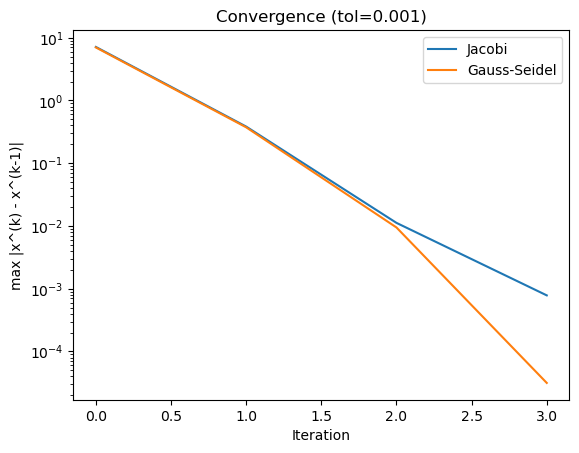

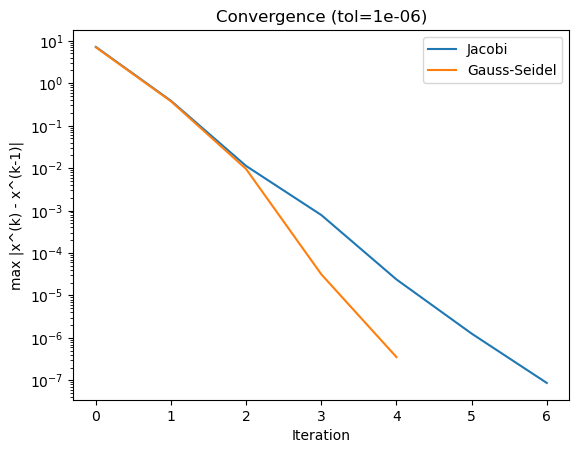

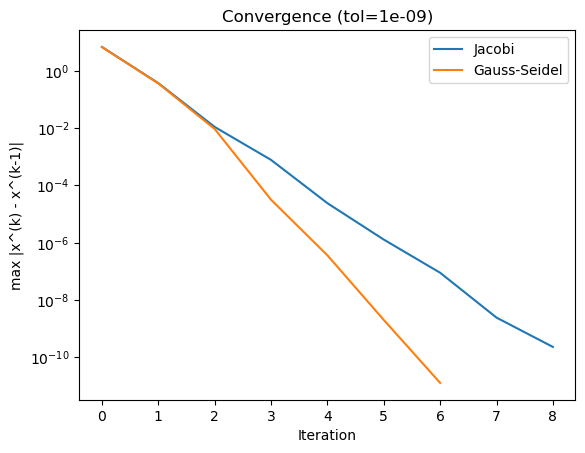

Discussion:
- Smaller tolerance (1e-9 vs 1e-3) requires more iterations because we demand a smaller change between steps.
- Gauss-Seidel usually converges in fewer iterations than Jacobi because it uses updated values immediately each sweep.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Small note: ChatGPT helped me clean up the stopping rule + plotting.

# System from the prompt
A = np.array([
    [3.0,  -0.1, -0.2],
    [0.1,   7.0, -0.3],
    [0.3,  -0.2, 10.0]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

x0 = np.array([0.0, 0.0, 0.0], dtype=float)
tols = [1e-3, 1e-6, 1e-9]


def jacobi(A, b, x0, tol, max_iter=200000):
    n = len(b)
    x = x0.copy()
    x_new = x0.copy()
    errs = []

    for it in range(1, max_iter + 1):
        for i in range(n):
            s = 0.0
            for j in range(n):
                if j != i:
                    s += A[i, j] * x[j]
            x_new[i] = (b[i] - s) / A[i, i]

        err = np.max(np.abs(x_new - x))
        errs.append(err)

        if err < tol:
            return x_new, it, np.array(errs)

        x[:] = x_new[:]

    return x, max_iter, np.array(errs)


def gauss_seidel(A, b, x0, tol, max_iter=200000):
    n = len(b)
    x = x0.copy()
    errs = []

    for it in range(1, max_iter + 1):
        x_old = x.copy()

        for i in range(n):
            s = 0.0
            for j in range(n):
                if j != i:
                    s += A[i, j] * x[j]
            x[i] = (b[i] - s) / A[i, i]

        err = np.max(np.abs(x - x_old))
        errs.append(err)

        if err < tol:
            return x, it, np.array(errs)

    return x, max_iter, np.array(errs)


# Run both methods for each tolerance
results = []
for tol in tols:
    xj, itj, ej = jacobi(A, b, x0, tol)
    xg, itg, eg = gauss_seidel(A, b, x0, tol)
    results.append((tol, xj, itj, ej, xg, itg, eg))

# Print iteration comparison (and final solutions)
print("Initial guess x0 =", x0.tolist())
print()
for tol, xj, itj, ej, xg, itg, eg in results:
    print("tol =", tol)
    print("  Jacobi iters:", itj, "x:", xj)
    print("  Gauss-Seidel iters:", itg, "x:", xg)
    print()

# Error analysis plots: absolute error between iterations (max norm)
for tol, xj, itj, ej, xg, itg, eg in results:
    plt.figure()
    plt.plot(ej, label="Jacobi")
    plt.plot(eg, label="Gauss-Seidel")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("max |x^(k) - x^(k-1)|")
    plt.title(f"Convergence (tol={tol})")
    plt.legend()
    plt.show()

# Short discussion (as printed notes)
print("Discussion:")
print("- Smaller tolerance (1e-9 vs 1e-3) requires more iterations because we demand a smaller change between steps.")
print("- Gauss-Seidel usually converges in fewer iterations than Jacobi because it uses updated values immediately each sweep.")